# **Image Stitching**
## !! CHANGE INPUT IMAGES HERE !!
## v v v v v v v v v v v v v v v v v

In [276]:
image1Location = 'leftImage.png'
image2Location = 'rightImage.png'

## ^^^^^^^^^^^^^^^^^^

Import libraries

In [277]:
from skimage.feature import corner_harris, corner_peaks
import matplotlib.pyplot as plt
import numpy as np
import cv2

Image prep

In [278]:
# function: make image gray
def makeGray(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    return gray

In [279]:
#grabbing the images based on locations provide ^^^
image1 = cv2.imread(image1Location)
image2 = cv2.imread(image2Location)

#gray version of each image
gray1 = makeGray(image1)
gray2 = makeGray(image2)

## 1. Harris Corner Detection
### **Function: harrisCornerDetection**

Does Harris Corner Detection on inputted image
Outputs keypoints and corner_harris response

In [280]:
def harrisCornerDetection(imgGray):
    response = corner_harris(imgGray)
    coords = corner_peaks(
        response,
        min_distance = 8,
        num_peaks = 1000,
        threshold_rel=0.0001
    )

    keypoints = np.array([[c[1], c[0]] for c in coords], dtype=np.float32)
    return keypoints, response

In [281]:
keypoints1, harrisResponse1 = harrisCornerDetection(gray1)
keypoints2, harrisResponse2 = harrisCornerDetection(gray2)

### **Function: visualHarrisCornerDetection**

Makes visual of keypoints on the image
For checking whether working & report

In [282]:
def visualHarrisCornerDetection(img, keypoints):
    vis = img.copy()
    if len(vis.shape) == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2RGB)

    for x, y in keypoints.astype(int):
        cv2.circle(vis, (x, y), 3, (255, 0, 0), -1)

    plt.figure(figsize=(8, 6))
    plt.imshow(vis, cmap="gray")
    plt.title("Keypoints")
    plt.axis("off")
    plt.show()

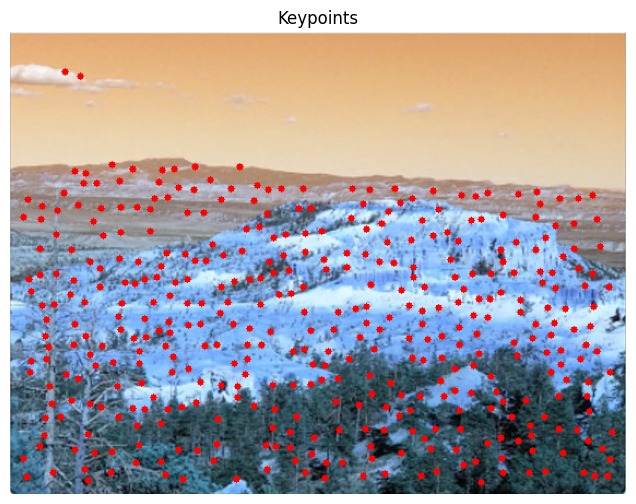

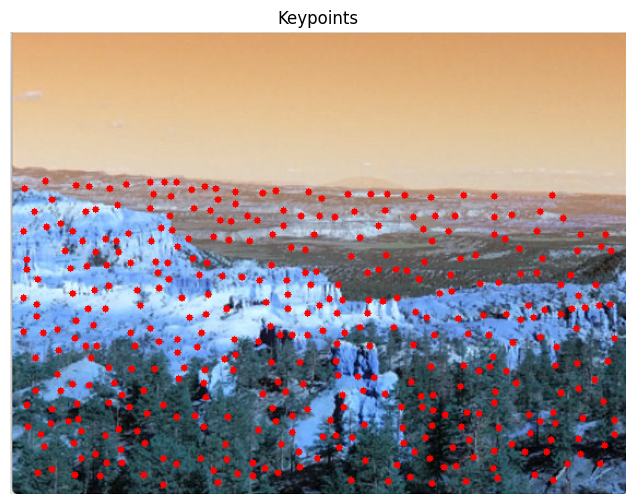

In [283]:
visualHarrisCornerDetection(image1, keypoints1)
visualHarrisCornerDetection(image2, keypoints2)

### **Function: patches**

Gets patch descriptors for the keypoints

In [284]:
def patches(imgGray, keypoints):
    patchSize = 11 #MUST BE AN ODD NUMBER
    half = patchSize // 2

    h, w = imgGray.shape
    valid_kps, descs = [], []

    for r, c in keypoints:
        if r - half < 0 or r + half + 1 > h or c - half < 0 or c + half + 1 > w:
            continue
        patch = imgGray[
            int(r - half):int(r + half + 1),
            int(c - half):int(c + half + 1)].copy()
        patch = patch.astype(np.float32)
        #zero-mean + unit-variance normalisation
        std = patch.std()
        if std < 1e-6:
            continue
        patch = (patch - patch.mean()) / std
        valid_kps.append((r, c))
        descs.append(patch.flatten())

    return np.array(valid_kps), np.array(descs, dtype=np.float32)

## 2. Sift (Optional)
### **Function: sift**
Gets SIFT descriptors for the keypoints

In [285]:
def sift(imgGray, keypoints):
    size = 16 #change if you want
    
    #change to uint8
    #(OpenCV SIFT didn't like the previous format)
    if imgGray.dtype != np.uint8:
        if imgGray.max() <= 1.0:
            imgGray = (imgGray * 255).astype(np.uint8)
        else:
            imgGray = np.clip(imgGray, 0, 255).astype(np.uint8)

    sift = cv2.SIFT_create()

    cv2_keypoints = [
        cv2.KeyPoint(float(x), float(y), size)
        for x, y in keypoints
    ]

    cv2_keypoints, descriptors = sift.compute(imgGray, cv2_keypoints)

    if descriptors is None or len(cv2_keypoints) == 0:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 128), dtype=np.float32)

    final_keypoints = np.array([[kp.pt[0], kp.pt[1]] for kp in cv2_keypoints], dtype=np.float32)
    return final_keypoints, descriptors.astype(np.float32)

## !! Do you want to use SIFT? !!
## v v v v v v v v v v v v v v v v v

In [286]:
#change to True or False
useSift = True

## ^^^^^^^^^^^^^^^^^^

In [287]:
if useSift:
    kp1desc, desc1 = sift(gray1, keypoints1)
    kp2desc, desc2 = sift(gray2, keypoints2)
else:
    kp1desc, desc1 = patches(gray1, keypoints1)
    kp2desc, desc2 = patches(gray2, keypoints2)

## 3. Distances between descriptors
Descriptors are already normalized :)
### a) Normalized correlation
**Function: normCorr**

In [288]:
def normCorr(d1, d2):
    return d1 @ d2.T

### b) Euclidean distance after normalizing each descriptor
**Function: euclidean**

In [289]:
def euclidean(d1, d2):
    d1sqr = np.sum(d1 ** 2, axis=1, keepdims=True)
    d2sqr = np.sum(d2 ** 2, axis=1, keepdims=True)
    distances = d1sqr + d2sqr - 2 * (d1 @ d2.T)
    distances = np.maximum(distances)
    return np.sqrt(distances)

## 4. Best matches
### Euclidean top matches